In [1]:
import pandas as pd
import numpy as np
from sklearn import linear_model
import matplotlib.pyplot as plt

In [19]:
df=pd.read_csv("D:/DS_AI_Internship/data/canada_per_capita_income.csv")
df.head()

,year,per capita income (US$)
0,1970,3399.299037
1,1971,3768.297935
2,1972,4251.175484
3,1973,4804.463248
4,1974,5576.514583


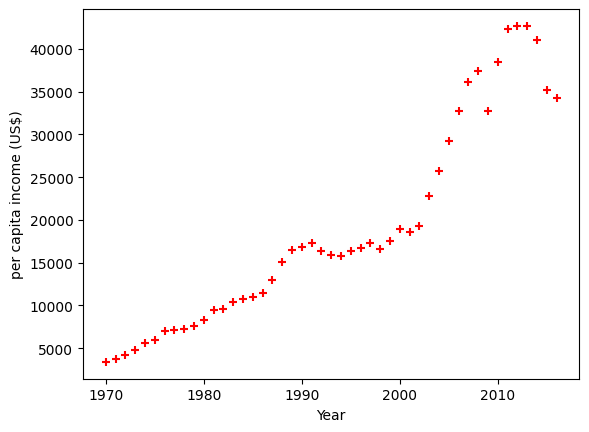

In [3]:
plt.xlabel("Year")
plt.ylabel("per capita income (US$)")
plt.scatter(df['year'],df['per capita income (US$)'],color="red",marker="+")
plt.show()

In [4]:
year=df.drop('per capita income (US$)',axis="columns")
year.head()

,year
0,1970
1,1971
2,1972
3,1973
4,1974


In [5]:
per_capita_income=df['per capita income (US$)']
per_capita_income

0      3399.299037
1      3768.297935
2      4251.175484
3      4804.463248
4      5576.514583
5      5998.144346
6      7062.131392
7      7100.126170
8      7247.967035
9      7602.912681
10     8355.968120
11     9434.390652
12     9619.438377
13    10416.536590
14    10790.328720
15    11018.955850
16    11482.891530
17    12974.806620
18    15080.283450
19    16426.725480
20    16838.673200
21    17266.097690
22    16412.083090
23    15875.586730
24    15755.820270
25    16369.317250
26    16699.826680
27    17310.757750
28    16622.671870
29    17581.024140
30    18987.382410
31    18601.397240
32    19232.175560
33    22739.426280
34    25719.147150
35    29198.055690
36    32738.262900
37    36144.481220
38    37446.486090
39    32755.176820
40    38420.522890
41    42334.711210
42    42665.255970
43    42676.468370
44    41039.893600
45    35175.188980
46    34229.193630
Name: per capita income (US$), dtype: float64

In [6]:
#Equation for linaer reg, y = mx+ c

reg=linear_model.LinearRegression()
reg.fit(year,per_capita_income)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [7]:
reg.coef_

array([828.46507522])

In [8]:
reg.intercept_

np.float64(-1632210.7578554575)

In [9]:
new_data=pd.DataFrame([[2020]],columns=['year'])
prediction=reg.predict(new_data)
prediction=np.round(prediction,2)
prediction

array([41288.69])

In [10]:
828.46507522*2020 -1632210.7578554575

41288.694088942604

In [21]:
p=reg.predict(df[['year']])
p=np.round(p,2)
p

array([ -134.56,   693.91,  1522.37,  2350.84,  3179.3 ,  4007.77,
        4836.23,  5664.7 ,  6493.16,  7321.63,  8150.09,  8978.56,
        9807.02, 10635.49, 11463.95, 12292.42, 13120.88, 13949.35,
       14777.81, 15606.28, 16434.74, 17263.21, 18091.67, 18920.14,
       19748.6 , 20577.07, 21405.53, 22234.  , 23062.46, 23890.93,
       24719.39, 25547.86, 26376.32, 27204.79, 28033.25, 28861.72,
       29690.18, 30518.65, 31347.11, 32175.58, 33004.04, 33832.51,
       34660.97, 35489.44, 36317.9 , 37146.37, 37974.83])

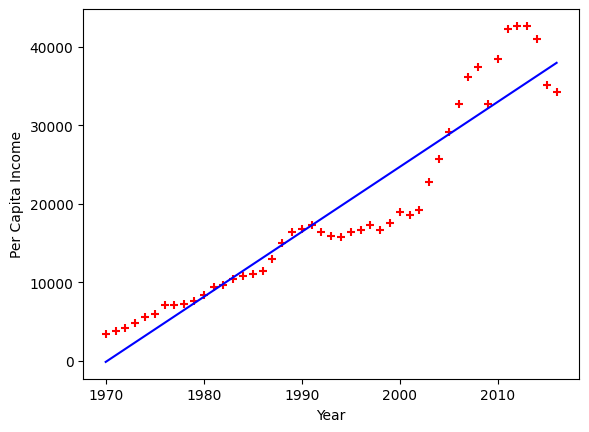

In [22]:
plt.xlabel("Year")
plt.ylabel("Per Capita Income")
plt.scatter(df.year,df['per capita income (US$)'],color="red",marker="+")
plt.plot(df.year,reg.predict(df[['year']]),color='blue')
plt.show()

In [13]:
reg.score(df[['year']],df['per capita income (US$)'])

0.890916917957032

In [23]:

future_years = pd.DataFrame({
    "year": np.arange(2020, 2031)
})

predictions = reg.predict(future_years)

print(predictions)

[41288.69409442 42117.15916964 42945.62424486 43774.08932009
 44602.55439531 45431.01947053 46259.48454575 47087.94962098
 47916.4146962  48744.87977142 49573.34484664]


In [24]:
future_df = pd.DataFrame({
    "Year": future_years["year"],
    "Predicted Income": predictions
})

print(future_df)

    Year  Predicted Income
0   2020      41288.694094
1   2021      42117.159170
2   2022      42945.624245
3   2023      43774.089320
4   2024      44602.554395
5   2025      45431.019471
6   2026      46259.484546
7   2027      47087.949621
8   2028      47916.414696
9   2029      48744.879771
10  2030      49573.344847


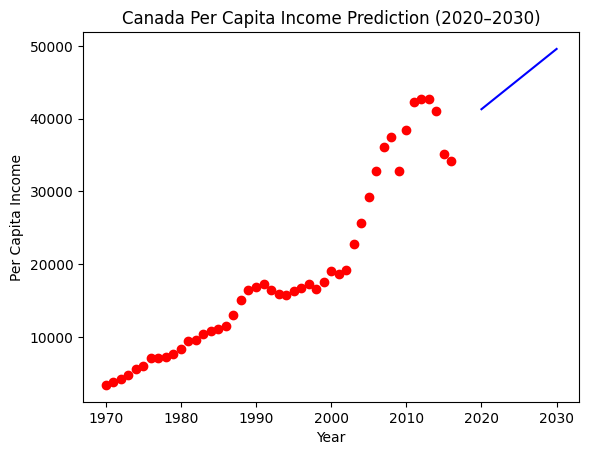

In [25]:
plt.scatter(df.year, df['per capita income (US$)'], color='red')
plt.plot(future_years, predictions, color='blue')

plt.xlabel("Year")
plt.ylabel("Per Capita Income")
plt.title("Canada Per Capita Income Prediction (2020–2030)")

plt.show()

In [26]:
future_df.to_csv("D:/DS_AI_Internship/data/Cleaned/canada_income_predictions_2021_2030.csv", index=False)